# 0.5 Client Clustering and Profile Analysis

The goal of this notebook is to group our 370 clients based on their consumption behavior (patterns) rather than their total volume. This allows us to train specialized models for specific groups (e.g., industrial vs. residential).

## 1. Imports

In [19]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

## 2. Hourly Profile Aggregation
We calculate the mean consumption for each of the 24 hours of the day across the entire dataset for every client. This results in a 370x24 matrix, where each row represents a client's "average day." Note: For a more advanced behavioral segmentation, we could separate Weekday and Weekend profiles into a 48-hour vector. Given the scope, a single 24-hour average profile serves as a robust baseline for capturing daily operational shifts

In [20]:
# We only load the columns needed for clustering to save RAM
print("Loading processed data...")
df = pd.read_parquet('../Datasets/processed_electricity_data.parquet', columns=['ClientID', 'Date', 'Hour', 'Consumption'])

# We use only data before 2014 (Training set) to define clusters
print("Filtering for training period to avoid Data Leakage...")
df_train = df[df['Date'].dt.year < 2014]

# Groupby on the filtered dataset
print("Creating average hourly profiles...")
profiles = df_train.groupby(['ClientID', 'Hour'], observed=True)['Consumption'].mean().unstack()

# Free up memory immediately
del df
del df_train

Loading processed data...
Filtering for training period to avoid Data Leakage...
Creating average hourly profiles...


## 3. Scaling by Row
Standardization is vital here. By applying a Min-Max scaler to each individual client, we remove the "volume" effect. This allows the K-Means algorithm to group a small shop and a large supermarket together if they both share a "9-to-5" consumption signature.

Normalizing profiles...
Calculating inertia for the Elbow Method...


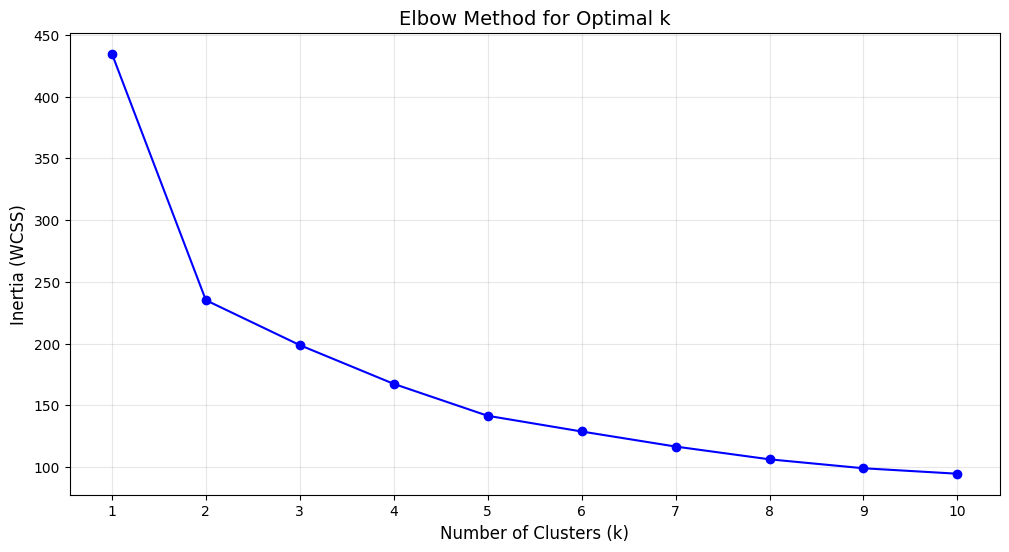

In [21]:
# Row-wise Normalization and Elbow Method
print("Normalizing profiles...")
scaler = MinMaxScaler()

# MinMaxScaler scales features (columns) by default. 
# We transpose the matrix (.T) to scale each client (row) individually, and then transpose it back to restore the original shape.
profiles_scaled = scaler.fit_transform(profiles.T).T
profiles_scaled = scaler.fit_transform(profiles.T).T

inertia = []
K_range = range(1, 11)

print("Calculating inertia for the Elbow Method...")
for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(profiles_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(12, 6))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
# K-Means Clustering (k=5)
n_clusters = 5
print(f"Running K-Means with {n_clusters} clusters...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(profiles_scaled)

mapping = pd.DataFrame({
    'ClientID': profiles.index,
    'Cluster':  cluster_labels
})

Running K-Means with 5 clusters...


## 4. Interpretation
The resulting plot helps us identify consumer types based strictly on historical training data (pre-2014). K-Means assigns cluster IDs dynamically, but looking at the hourly distribution, the behavioral patterns are distinct:

- **Cluster 0 (Blue - 161 clients)**: Standard Daytime Office/Business. This group shows a steady plateau during standard working hours (9:00 AM to 6:00 PM) and sharply drops after 6:00 PM when employees leave for the day.

- **Cluster 1 (Orange - 87 clients)**: Standard Residential. Consumption rises in the morning and remains high throughout the evening until late night (around 10:00 PM), reflecting typical household behavior where peak energy use occurs after work hours.

- **Cluster 2 (Green - 36 clients)**: Split-Shift/Siesta Profile. These clients have a sharp peak at noon followed by a visible dip around 2:00 PM - 3:00 PM, a classic "siesta" signature common in Portuguese commercial districts.

- **Cluster 3 (Red - 71 clients)**: Extended Hours Commercial / Mixed-Use. Similar to the residential shape but starting earlier and maintaining a higher, broader plateau. This points to businesses open late (restaurants, retail) or mixed-use buildings.

- **Cluster 4 (Purple - 15 clients)**: Night-Shift Industrial. This unique group shows peak consumption from midnight to 6:00 AM, with a significant drop during daylight hours.

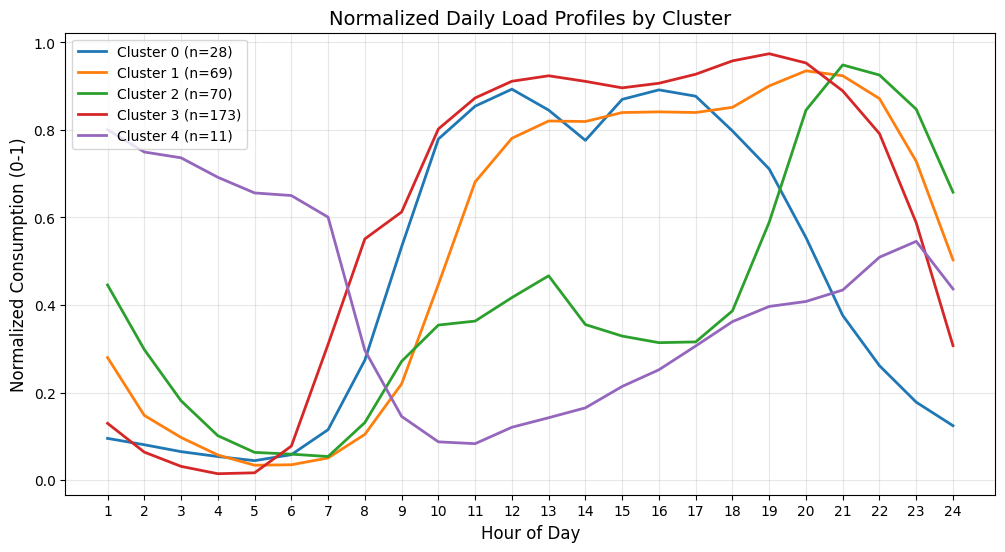

In [23]:
# Cluster Profile Visualization
plt.figure(figsize=(12, 6))
for i in range(n_clusters):
    cluster_mean = profiles_scaled[cluster_labels == i].mean(axis=0)
    plt.plot(range(1, 25), cluster_mean, label=f'Cluster {i} (n={sum(cluster_labels == i)})', linewidth=2)

plt.title('Normalized Daily Load Profiles by Cluster', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Normalized Consumption (0-1)', fontsize=12)
plt.xticks(range(1, 25))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
# Save Cluster Mapping
print("Saving cluster mapping...")
mapping.to_csv('../Datasets/client_clusters.csv', index=False)

Saving cluster mapping...
